## Imports and config

### Make sure the paths in the config are correct

In [17]:
import os
import os.path as osp
import sys
module_path = os.path.abspath(os.path.join('../..'))
sys.path.append(module_path)
from src.utils.db import DatabaseManager
from src.utils.process_config import load_config
from itables import show
import pandas as pd

import numpy as np

config_path = os.path.join(module_path, 'src', 'config', 'edit_192_external.json')

class Args:
    def __init__(self, config):
        self.config = config
args = Args(config=config_path)
config = load_config(args.config)
dbm = DatabaseManager(config)
print("Database manager initialized from config:", config_path)
dbm.print_db_schema_counts()





Database manager initialized from config: /home/adml/Research/Hackathon2026/IDETC26-Hackathon-Autodesk-neuralCAD-Edit/src/config/edit_192_external.json
Collection: users, Count: 27
Collection: breps, Count: 528
Collection: edits, Count: 480
Collection: requests, Count: 48
Collection: ratings, Count: 2340


In [18]:
# test rater - make sure to remove before calculating human ratings
exclude_raters = ["private.us-west-2.0fe3ef0902668b13"]

# columns to show in the leaderboard
# currently-enabled metrics first, then the remaining columns
score_columns = [
    "chamfer sim norm",
    "volume f1",
    "diff f1",
    "chamfer vs human",
    "volume f1 vs human",
    "diff f1 vs human",
    "dino v2 sim",
    "validity",
    "claude instruction",
    "claude quality",
    "claude acceptance",
    "gemini instruction",
    "gemini quality",
    "gemini acceptance",
    "gpt instruction",
    "gpt quality",
    "gpt acceptance",
    "human instruction",
    "human quality",
    "human acceptance",
]

# users to show in the leaderboard
users = [
    "human requestor",
    "human baseline",
    "claude-sonnet-4.5_cadquery-script",
    "gemini-3-pro_cadquery-script",
    "gpt-5.2_cadquery-script",
    "gpt-5.2-ours_cadquery-script",
    "gpt-5.6-sol-base_cadquery-script",
    "gpt-5.6-sol-ontology_cadquery-script",
    "gpt-5.6-sol-ontologies_cadquery-script",
    "gpt-5.6-sol-final_cadquery-script",
]


rating_keys = []
user_name_mapping = {}
all_edits = {}
for edt in dbm.edits.find({}):
    all_edits[edt["_id"]] = {}

for rating in dbm.ratings.find({}):
    edit_id = rating["edit"]
    ignore_keys = ["_id", "edit", "user", 'result_info', 'job_info', 'submission_time', 'comments', 'flags']
    existing_edit = all_edits.get(edit_id, {})
    
    rating_user = rating["user"]

    existing_rating_user = existing_edit.get(rating_user, {})

    # only add keys that are not in ignore_keys
    for k, v in rating.items():
        if k not in ignore_keys:
            existing_rating_user[k] = v

    #update the edit's ratings with the new rating
    existing_edit[rating_user] = existing_rating_user
    all_edits[edit_id] = existing_edit

def process_single_rating(rating):
    # instruction and qualitiy human/vlm ratings have different defaults for doing nothing/failed runs according to the scoring rubric.

    new_rating = {}
    similarity_eval = rating.get("similarity_eval", {})
    # currently-enabled metrics
    new_rating["dino v2 sim"] = similarity_eval.get("dino similarity gt", 0.0)
    new_rating["chamfer sim norm"] = similarity_eval.get("chamfer similarity norm gt", 0.0)
    new_rating["volume f1"] = similarity_eval.get("volume f1 gt", 0.0)
    new_rating["diff f1"] = similarity_eval.get("diff f1 gt", 0.0)
    new_rating["chamfer vs human"] = similarity_eval.get("chamfer similarity norm human", 0.0)
    new_rating["volume f1 vs human"] = similarity_eval.get("volume f1 human", 0.0)
    new_rating["diff f1 vs human"] = similarity_eval.get("diff f1 human", 0.0)

    gemini_dict = rating.get('gemini-3-pro_30-720_edit-rating-6-img', {})
    new_rating["gemini instruction"] = (gemini_dict.get("score_instr", 2) - 1 ) / 6.0
    new_rating["gemini quality"] = (gemini_dict.get("score_quality", 1) - 1 ) / 6.0

    gpt_dict = rating.get('gpt-5.2_edit-rating-6-img', {})
    new_rating["gpt instruction"] = (gpt_dict.get("score_instr", 2) - 1 ) / 6.0
    new_rating["gpt quality"] = (gpt_dict.get("score_quality", 1) - 1 ) / 6.0

    claude_dict = rating.get('claude-sonnet-4.5_edit-rating-6-img', {})
    new_rating["claude instruction"] = (claude_dict.get("score_instr", 2) - 1 ) / 6.0
    new_rating["claude quality"] = (claude_dict.get("score_quality", 1) - 1 ) / 6.0

    instruction_threshold = (5-1) / 6.0
    quality_threshold = (5-1) / 6.0

    human_instruction = []
    human_quality = []

    for k, v in rating.items():
        if "private" in k and k not in exclude_raters:
            for pk, pv in v.items():
                instr=False
                quality=False
                if "instr" in pk:
                    if pv is not None and pv == pv:
                        score = (pv - 1) / 6.0
                        human_instruction.append(score)
                        instr=True
                if "quality" in pk:
                    if pv is not None and pv == pv:
                        score = (pv - 1) / 6.0
                        human_quality.append(score)
                        quality=True
    new_rating["human instruction"] = float(np.median(human_instruction)) if human_instruction else 1/6.0
    new_rating["human quality"] = float(np.median(human_quality)) if human_quality else 0/6.0
    new_rating["human acceptance"] = float(new_rating["human instruction"] >= instruction_threshold and new_rating["human quality"] >= quality_threshold)
    new_rating["gemini acceptance"] = float(new_rating["gemini instruction"] >= instruction_threshold and new_rating["gemini quality"] >= quality_threshold)
    new_rating["gpt acceptance"] = float(new_rating["gpt instruction"] >= instruction_threshold and new_rating["gpt quality"] >= quality_threshold)
    new_rating["claude acceptance"] = float(new_rating["claude instruction"] >= instruction_threshold and new_rating["claude quality"] >= quality_threshold)
    return new_rating


for k, v in all_edits.items():
    new_rating = process_single_rating(v)
    new_rating["edit_id"] = k
    new_rating["request_id"] = dbm.edits.find_one({"_id": k})["request"]

    edit_user_id = dbm.edits.find_one({"_id": k})["user"]
    request_user_id = dbm.requests.find_one({"_id": new_rating["request_id"]})["user"]
    edit_user = dbm.users.find_one({"_id": edit_user_id})
    request_user = dbm.users.find_one({"_id": request_user_id})
    new_rating["modality"] = dbm.requests.find_one({"_id": new_rating["request_id"]}).get("modality")

    if edit_user["is_human"]:
        if edit_user_id == request_user_id:
            new_rating["edit_user"] = "human requestor"
            new_rating["chamfer sim norm"] = 1.0
            new_rating["volume f1"] = 1.0
            new_rating["diff f1"] = 1.0
        else:
            new_rating["edit_user"] = "human baseline"
            # identity vs the other-human reference used for "vs human" metrics
            new_rating["chamfer vs human"] = 1.0
            new_rating["volume f1 vs human"] = 1.0
            new_rating["diff f1 vs human"] = 1.0
    else:
        new_rating["edit_user"] = edit_user_id

    # validity entry - checks that there is an iso1 (or legacy toprightiso) preview
    brep_id = dbm.edits.find_one({"_id": k})["brep_end"]
    images = dbm.get_brep_images(brep_id, views=["iso1"], format=["jpg", "png"])
    if images is not None and len(images) > 0:
        new_rating["validity"] = 1
    else:
        new_rating["validity"] = 0

    difficulty = dbm.requests.find_one({"_id": new_rating["request_id"]}).get("difficulty")
    new_rating["difficulty"] = difficulty

    all_edits[k] = new_rating

# turn into dataframe, with edit_id as index
df = pd.DataFrame.from_dict(all_edits, orient='index')

# Filter to only the specified users
df_filtered = df[df["edit_user"].isin(users)].copy()
df_melted = df_filtered.melt(id_vars=["edit_user"], value_vars=score_columns, var_name="Metric", value_name="Score")
df_grouped = df_melted.groupby(["edit_user", "Metric"], as_index=False)["Score"].mean()

# Enforce the desired user order and score order
df_grouped["edit_user"] = pd.Categorical(df_grouped["edit_user"], categories=users, ordered=True)
df_grouped["Metric"] = pd.Categorical(df_grouped["Metric"], categories=score_columns, ordered=True)
df_grouped = df_grouped.sort_values(["edit_user", "Metric"])

df_pivot_scores = df_grouped.pivot(index="edit_user", columns="Metric", values="Score")
df_pivot_scores = df_pivot_scores.reindex(index=users, columns=score_columns)

# set all values to 2 decimal places
df_pivot_scores = df_pivot_scores.round(4)

# Print results as tab-separated table for pasting into spreadsheet
# Print header
print("\t".join(["edit_user"] + score_columns))
# Print rows
for user in users:
    row_values = [f"{df_pivot_scores.loc[user, col]:.4f}" for col in score_columns]
    print("\t".join([user] + row_values))

# print results in nice table using itables
show(df_pivot_scores)





No images found for format ['jpg', 'png'] in brep gemini-3-pro_cadquery-script_1771007562.564814.
No images found for format ['jpg', 'png'] in brep claude-sonnet-4.5_cadquery-script_1771491522.64626.
No images found for format ['jpg', 'png'] in brep claude-sonnet-4.5_cadquery-script_1771473521.805957.
No images found for format ['jpg', 'png'] in brep claude-sonnet-4.5_cadquery-script_1771472566.8134458.
No images found for format ['jpg', 'png'] in brep claude-sonnet-4.5_cadquery-script_1771586778.256877.
No images found for format ['jpg', 'png'] in brep claude-sonnet-4.5_cadquery-script_1771443059.2790122.
No images found for format ['jpg', 'png'] in brep claude-sonnet-4.5_cadquery-script_1771464127.7421372.
No images found for format ['jpg', 'png'] in brep claude-sonnet-4.5_cadquery-script_1771442086.86292.
No images found for format ['jpg', 'png'] in brep claude-sonnet-4.5_cadquery-script_1771453792.894491.
No images found for format ['jpg', 'png'] in brep claude-sonnet-4.5_cadquery-

Saved /home/adml/Research/Hackathon2026/IDETC26-Hackathon-Autodesk-neuralCAD-Edit/data/edit_192_external/results/leaderboard_fig1.png
cell_3:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


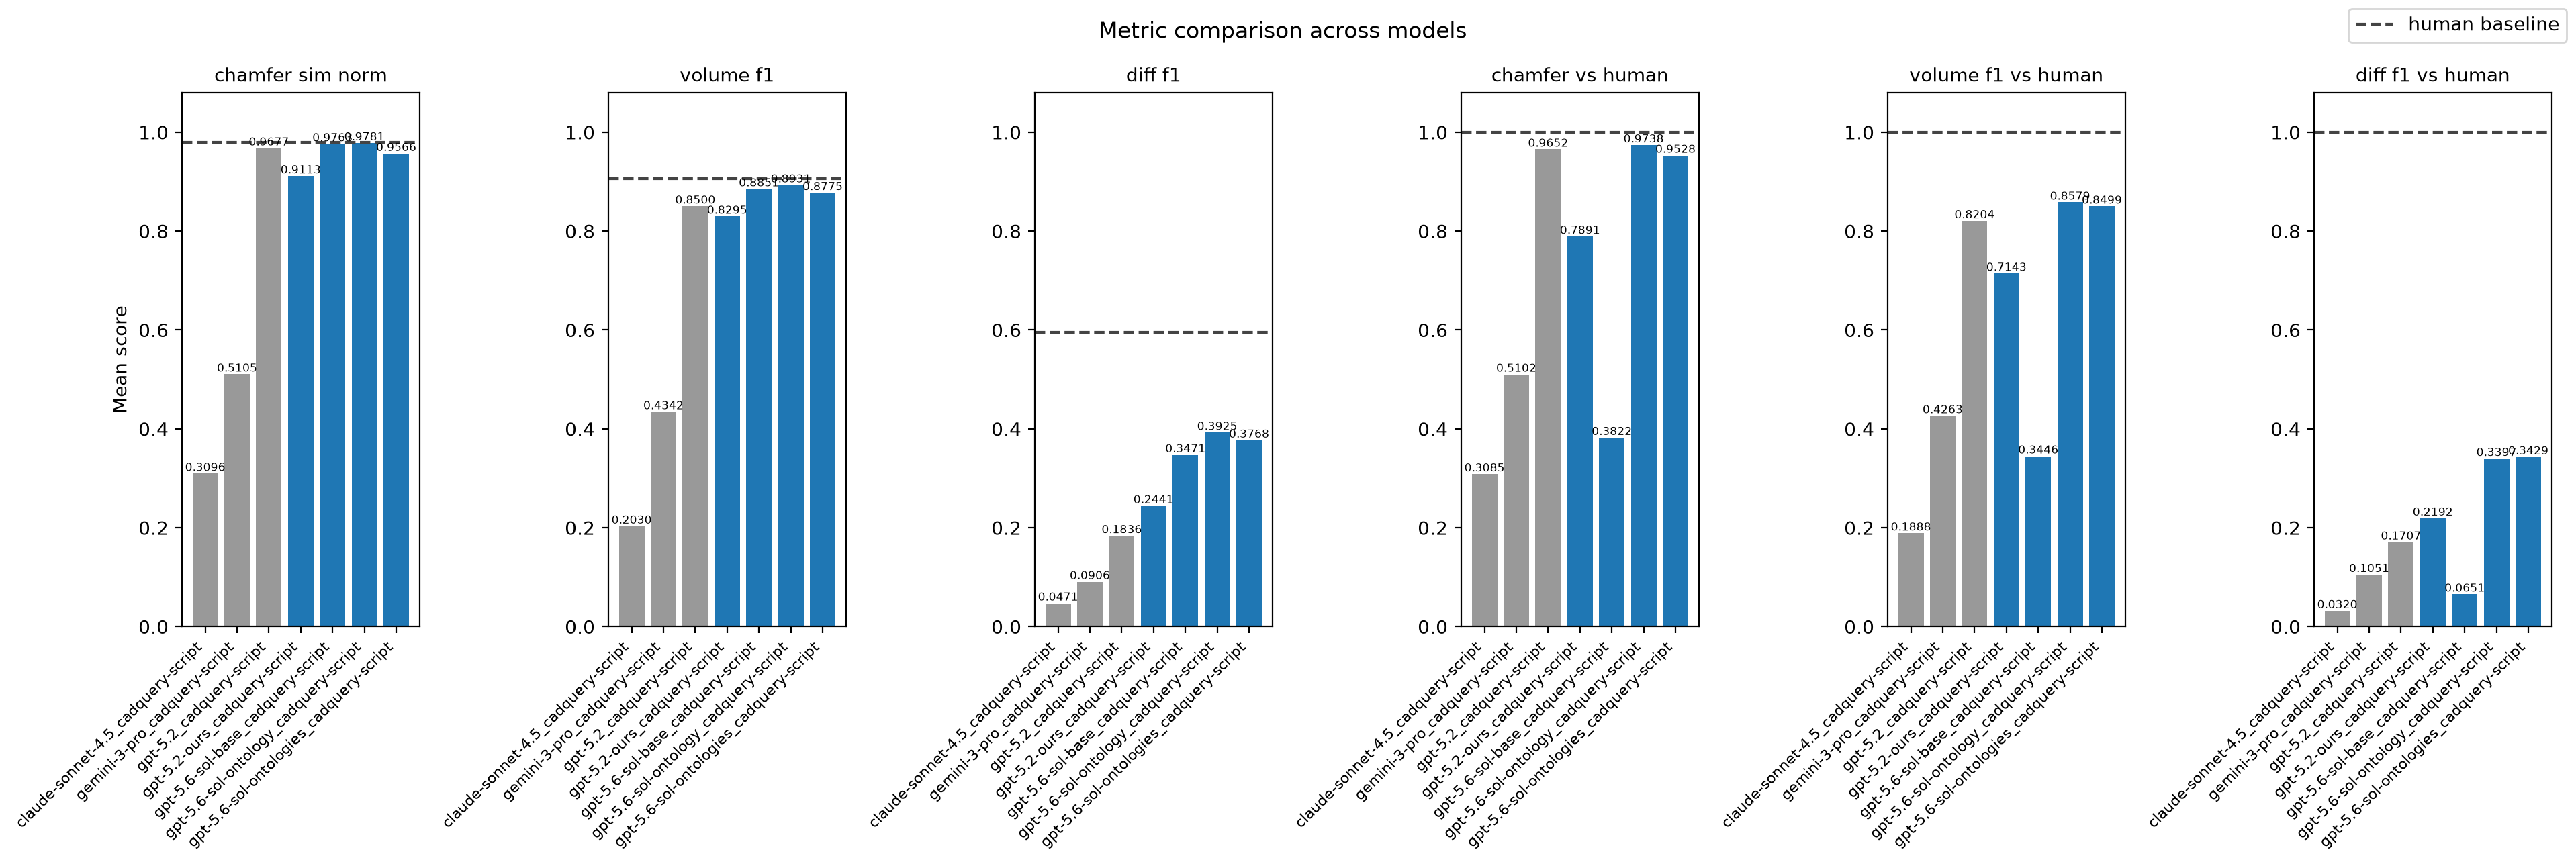

In [19]:
import matplotlib.pyplot as plt
from src.utils.visualise_results import plot_metric_facets

facet_metrics = [
    "chamfer sim norm",
    "volume f1",
    "diff f1",
    "chamfer vs human",
    "volume f1 vs human",
    "diff f1 vs human",
]
bar_users = [u for u in users if u not in ("human requestor", "human baseline")]


def _means_from_df(data_df):
    means_by_metric = {}
    baseline_means = {}
    for metric in facet_metrics:
        means_by_metric[metric] = {}
        for u in bar_users:
            vals = data_df[data_df["edit_user"] == u][metric]
            mean = vals.mean()
            means_by_metric[metric][u] = 0.0 if mean != mean else float(mean)
        base_vals = data_df[data_df["edit_user"] == "human baseline"][metric]
        baseline_means[metric] = (
            float(base_vals.mean()) if len(base_vals) > 0 and base_vals.notna().any() else None
        )
    return means_by_metric, baseline_means


means_by_metric, baseline_means = _means_from_df(df_filtered)
fig, axes = plot_metric_facets(
    means_by_metric,
    bar_users,
    metrics=facet_metrics,
    baseline_means=baseline_means,
    metric_titles={m: m for m in facet_metrics},
    suptitle="Metric comparison across models",
)
fig1_path = osp.join(module_path, "data", "edit_192_external", "results", "leaderboard_fig1.png")
fig.savefig(fig1_path, dpi=200, bbox_inches="tight")
print(f"Saved {fig1_path}")
plt.show()

Saved /home/adml/Research/Hackathon2026/IDETC26-Hackathon-Autodesk-neuralCAD-Edit/data/edit_192_external/results/leaderboard_fig2.png
cell_4:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


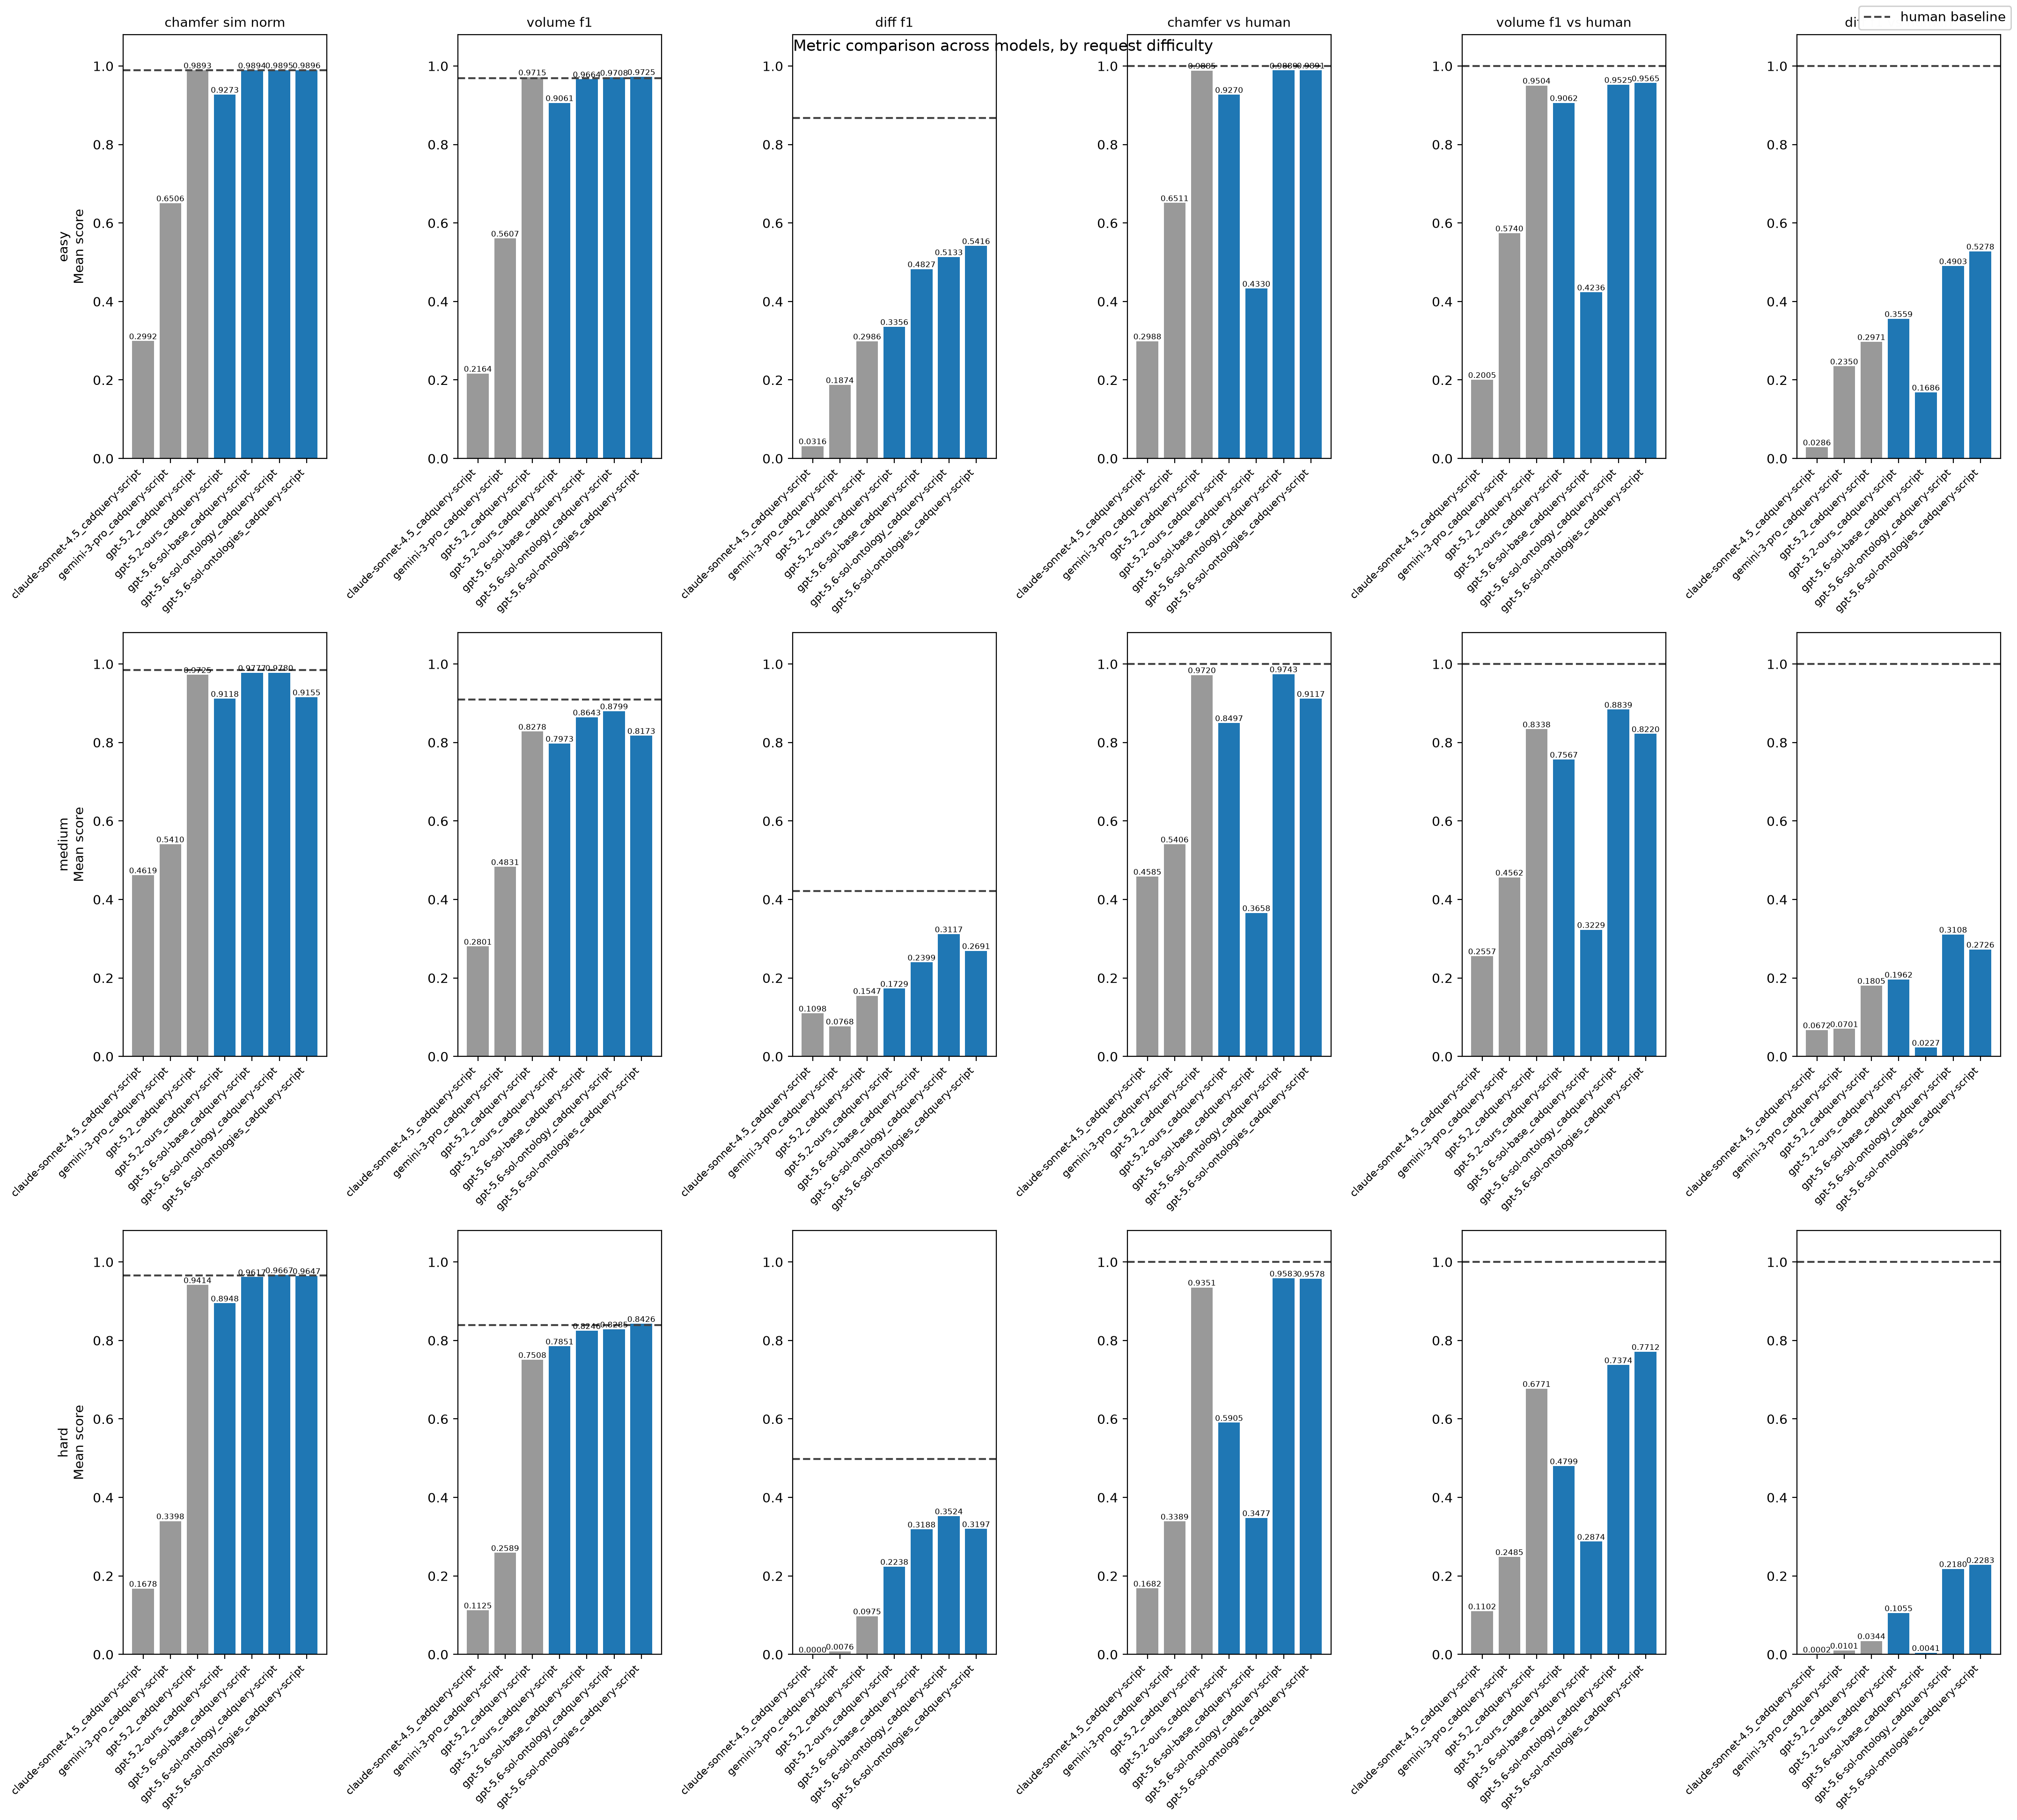

In [20]:
# Breakdown by request difficulty: one row per difficulty, one facet per metric.
difficulties = ["easy", "medium", "hard"]

fig, axes_grid = plt.subplots(
    len(difficulties), len(facet_metrics),
    figsize=(3.6 * len(facet_metrics), 6.5 * len(difficulties)),
    squeeze=False,
)

for row, difficulty in enumerate(difficulties):
    diff_df = df_filtered[df_filtered["difficulty"] == difficulty]
    means_by_metric, baseline_means = _means_from_df(diff_df)
    plot_metric_facets(
        means_by_metric,
        bar_users,
        metrics=facet_metrics,
        baseline_means=baseline_means,
        axes=axes_grid[row],
        show_titles=(row == 0),
        row_label=difficulty,
        metric_titles={m: m for m in facet_metrics},
    )

fig.suptitle("Metric comparison across models, by request difficulty")
fig2_path = osp.join(module_path, "data", "edit_192_external", "results", "leaderboard_fig2.png")
fig.savefig(fig2_path, dpi=200, bbox_inches="tight")
print(f"Saved {fig2_path}")
plt.show()